In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd

In [3]:
from hypex import AATest
from hypex.dataset import (
    Dataset,
    ExperimentData,
    FeatureRole,
    StatisticRole,
    TargetRole,
    TreatmentRole,
)
from hypex.experiments import ParamsExperiment
from hypex.utils import ExperimentDataEnum

/home/eric/.local/lib/python3.8/site-packages/pyspark/pandas/__init__.py:50: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


In [4]:
import os
import time
from pyspark.sql import SparkSession
from hypex.utils.spark_config import SparkSessionCalculator

# --- 1. Настройки окружения для macOS (Важно!) ---
os.environ['OBJC_DISABLE_INITIALIZE_FORK_SAFETY'] = 'YES'

# Очистка старых сессий и переменных
try:
    existing_spark = SparkSession.getActiveSession()
    if existing_spark:
        existing_spark.stop()
        print("✅ Существующая сессия остановлена.")
except:
    pass

for key in list(os.environ.keys()):
    if 'SPARK' in key or 'JAVA_OPTS' in key:
        del os.environ[key]

# --- 2. Конфигурация для калькулятора ---
NUM_EXECUTORS = 2
CORES_PER_EXECUTOR = 4
MEMORY_PER_EXECUTOR_MB = 2048

# Параметры для калькулятора (на основе вашего датасета)
n_rows = 10_000
n_columns = 7
n_categorical = 1

# --- 3. Создание и использование калькулятора ---
calculator = SparkSessionCalculator(
    data_size_bytes=n_rows * n_columns * 8,  # Примерная оценка
    num_columns=n_columns,
    num_categorical_columns=n_categorical,
    target_executor_cores=CORES_PER_EXECUTOR,
    target_executor_memory_gb=MEMORY_PER_EXECUTOR_MB / 1024
)

# Получаем оптимальные настройки
optimal_settings = calculator.calculate_optimal_settings()

print("\n📊 Оптимальные настройки от калькулятора:")
print(f"  Executor instances: {optimal_settings.executor_instances}")
print(f"  Executor cores: {optimal_settings.executor_cores}")
print(f"  Executor memory: {optimal_settings.executor_memory}")
print(f"  Shuffle partitions: {optimal_settings.shuffle_partitions}")

# --- 4. Создание Spark-сессии с настройками калькулятора ---
MASTER_URL = f"local-cluster[{NUM_EXECUTORS}, {CORES_PER_EXECUTOR}, {MEMORY_PER_EXECUTOR_MB}]"
print(f"\n🚀 Запуск в режиме: {MASTER_URL}")

builder = (SparkSession.builder
    .master(MASTER_URL)
    .appName("LocalClusterTest")
    # Настройки драйвера
    .config("spark.driver.memory", "2g")
    # Настройки executor'ов из калькулятора
    .config("spark.executor.memory", f"{MEMORY_PER_EXECUTOR_MB}m")
    .config("spark.executor.cores", str(CORES_PER_EXECUTOR))
    .config("spark.executor.instances", str(NUM_EXECUTORS))
    # Дополнительные настройки из калькулятора
    .config("spark.memory.fraction", str(optimal_settings.memory_fraction))
    .config("spark.sql.shuffle.partitions", str(optimal_settings.shuffle_partitions))
    .config("spark.serializer", optimal_settings.serializer)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.cleaner.referenceTracking.cleanCheckpoints", "true")
)

sp_s = builder.getOrCreate()
sp_s.sparkContext.setLogLevel("WARN")

# --- 5. Проверка конфигурации ---
print(f"\n✅ Сессия создана.")
print(f"Driver Memory Config: {sp_s.conf.get('spark.driver.memory')}")
print(f"Executor Memory Config: {sp_s.conf.get('spark.executor.memory')}")
print(f"Shuffle Partitions: {sp_s.conf.get('spark.sql.shuffle.partitions')}")

# Проверка количества экзекуторов
time.sleep(3)
num_executors = len(sp_s.sparkContext.parallelize(range(10), NUM_EXECUTORS).glom().collect())
print(f"📊 Активных экзекуторов (проверка через RDD): {num_executors}")

# --- 6. Тест на распределение ---
def print_executor_info(iterator):
    import os
    executor_id = os.environ.get('SPARK_EXECUTOR_ID', 'Driver/Local')
    process_id = os.getpid()
    return [f"Executor ID: {executor_id}, PID: {process_id}"]

df = sp_s.range(0, 10, 1, 4)
result = df.rdd.mapPartitions(print_executor_info).collect()

print("\n🖥️ Где выполнялись задачи:")
for line in result:
    print(line)

# sp_s.stop()  # Раскомментируйте, если нужно остановить сессию


📊 Оптимальные настройки от калькулятора:
  Executor instances: 4
  Executor cores: 4
  Executor memory: 4g
  Shuffle partitions: 10

🚀 Запуск в режиме: local-cluster[2, 4, 2048]


26/09/16 11:47:40 WARN Utils: Your hostname, eric-Katana-17-B12UCR resolves to a loopback address: 127.0.1.1; using 10.240.72.75 instead (on interface wlo1)
26/09/16 11:47:40 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/16 11:47:40 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable



✅ Сессия создана.
Driver Memory Config: 2g
Executor Memory Config: 2048m
Shuffle Partitions: 10


📊 Активных экзекуторов (проверка через RDD): 2



🖥️ Где выполнялись задачи:
Executor ID: Driver/Local, PID: 218487
Executor ID: Driver/Local, PID: 218486
Executor ID: Driver/Local, PID: 218551
Executor ID: Driver/Local, PID: 218542


In [4]:
n_rows = 10000
n = n_rows
df = pd.DataFrame({
    "treatment": np.random.choice([0, 1], size=n, p=[0.6, 0.4]),
    "feat_num_1": np.random.normal(loc=10, scale=3, size=n),
    "feat_num_2": np.random.normal(loc=-2, scale=1.5, size=n),
    "feat_cat": np.random.choice(["A", "B", "C"], size=n),
    "target": np.random.normal(loc=100, scale=10, size=n)
})

In [5]:
roles = {
    "treatment": TreatmentRole(),
    "feat_num_1": FeatureRole(),
    "feat_num_2": TargetRole(),
    "feat_cat": FeatureRole(str),
    "target": TargetRole(),
}

# dataset = Dataset(
#     roles=roles,
#     data=sp_s.createDataFrame(df),
#     session=sp_s
# )
dataset = Dataset(
    roles=roles,
    data=df
)
dataset

,treatment,feat_num_1,feat_num_2,feat_cat,target
0,0,10.368515,-3.130278,A,107.846245
1,1,5.728881,-3.94472,B,99.802488
2,1,3.215086,-1.734329,B,107.711113
3,0,10.682765,-0.361295,C,98.597279
4,1,10.735342,-1.313437,C,101.393956
...,...,...,...,...,...
9995,0,6.596279,-2.79021,C,118.094231
9996,0,13.624202,-3.722986,A,98.912765
9997,0,10.590396,-2.981963,C,99.851894
9998,0,11.468751,-1.259135,B,106.892513


In [6]:
exp = AATest(n_iterations=10, dry_test=True)
exс = exp.experiment
exс

Experiment(executors=[ParamsExperiment(executors=[Experiment(executors=[NaDropper(target_roles=Target(None), how='any', key=''), AASplitter(control_size=0.5, random_state=None, sample_size=None, constant_key=True, save_groups=True, groups_sizes=None, key=''), Experiment(executors=[GroupSizes(compare_by='groups', grouping_role=AdditionalTreatment(None)), OnRoleExperiment(executors=[GroupDifference(compare_by='groups', grouping_role=AdditionalTreatment(None), target_roles=Target(None)), TTest(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key=''), KSTest(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key=''), Chi2Test(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key='')], role=[Target(None), Feature()], transformer=False, key=''), OneAAStatAnalyzer(key='')], transformer=False, key='')], transformer=True, key='')], reporter=<hypex.reporters.abstract.DatasetReporter object at 0x7fde09587760>, params={<class 'hypex.splitters.aa.AASplitter'>: {'random_state': range(0, 10), 'control_size': [0.5], 'sample_size': [None], 'groups_sizes': [None]}, <class 'hypex.comparators.abstract.GroupsComparator'>: {'grouping_role': [AdditionalTreatment(None)], 'space': [<SpaceEnum.additional: 'additional'>]}}, transformer=False, key=''), AADryTestAnalyzer(alpha=0.05, key=''), AAScoreAnalyzer(alpha=0.05, key='')], transformer=False, key='AATest')

In [7]:
exp_data = ExperimentData(dataset)
result = exp.execute(exp_data)

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:07<00:00,  1.41it/s]


AttributeError: 'AAOutput' object has no attribute '_get_dry_score'

In [18]:
result.resume

,feature,group,TTest aa score,TTest best split,KSTest aa score,KSTest best split,result,control mean,test mean,difference,difference %
0,feat_num_1,test_1,OK,OK,OK,OK,OK,10.004304,10.013581,0.009277,0.092728
1,feat_num_2,test_1,OK,OK,OK,OK,OK,-1.995573,-2.002595,-0.007022,0.351899
2,target,test_1,OK,OK,OK,OK,OK,99.864640,99.932369,0.067729,0.067821


In [19]:
result.aa_score

,score,p-value,pass
feat_num_1 TTest test_1,0.95,NaN,True
feat_num_2 TTest test_1,0.95,0.730038,True
target TTest test_1,0.95,0.624978,True
feat_num_1 KSTest test_1,0.95,NaN,True
feat_num_2 KSTest test_1,0.95,NaN,True
target KSTest test_1,0.95,NaN,True


In [32]:
exс

Experiment(executors=[ParamsExperiment(executors=[Experiment(executors=[NaDropper(target_roles=Target(None), how='any', key=''), AASplitter(control_size=0.5, random_state=499, sample_size=None, constant_key=True, save_groups=True, groups_sizes=None, key=''), Experiment(executors=[GroupSizes(compare_by='groups', grouping_role=AdditionalTreatment(None)), OnRoleExperiment(executors=[GroupDifference(compare_by='groups', grouping_role=AdditionalTreatment(None), target_roles=Target(None)), TTest(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key=''), KSTest(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key=''), Chi2Test(grouping_role=AdditionalTreatment(None), target_roles=Target(None), baseline_role=PreTarget(), reliability=0.05, compare_by='groups', key='')], role=[Target(None), Feature()], transformer=False, key=''), OneAAStatAnalyzer(key='')], transformer=False, key='')], transformer=True, key='')], reporter=<hypex.reporters.abstract.DatasetReporter object at 0x7fd6fc134df0>, params={<class 'hypex.splitters.aa.AASplitter'>: {'random_state': range(0, 500), 'control_size': [0.5], 'sample_size': [None], 'groups_sizes': [None]}, <class 'hypex.comparators.abstract.GroupsComparator'>: {'grouping_role': [AdditionalTreatment(None)], 'space': [<SpaceEnum.additional: 'additional'>]}}, transformer=False, key='AATest'), AAScoreAnalyzer(alpha=0.05, key='best splitter'), AADryTestAnalyzer(alpha=0.05, key='AATest')], transformer=False, key='AATest')

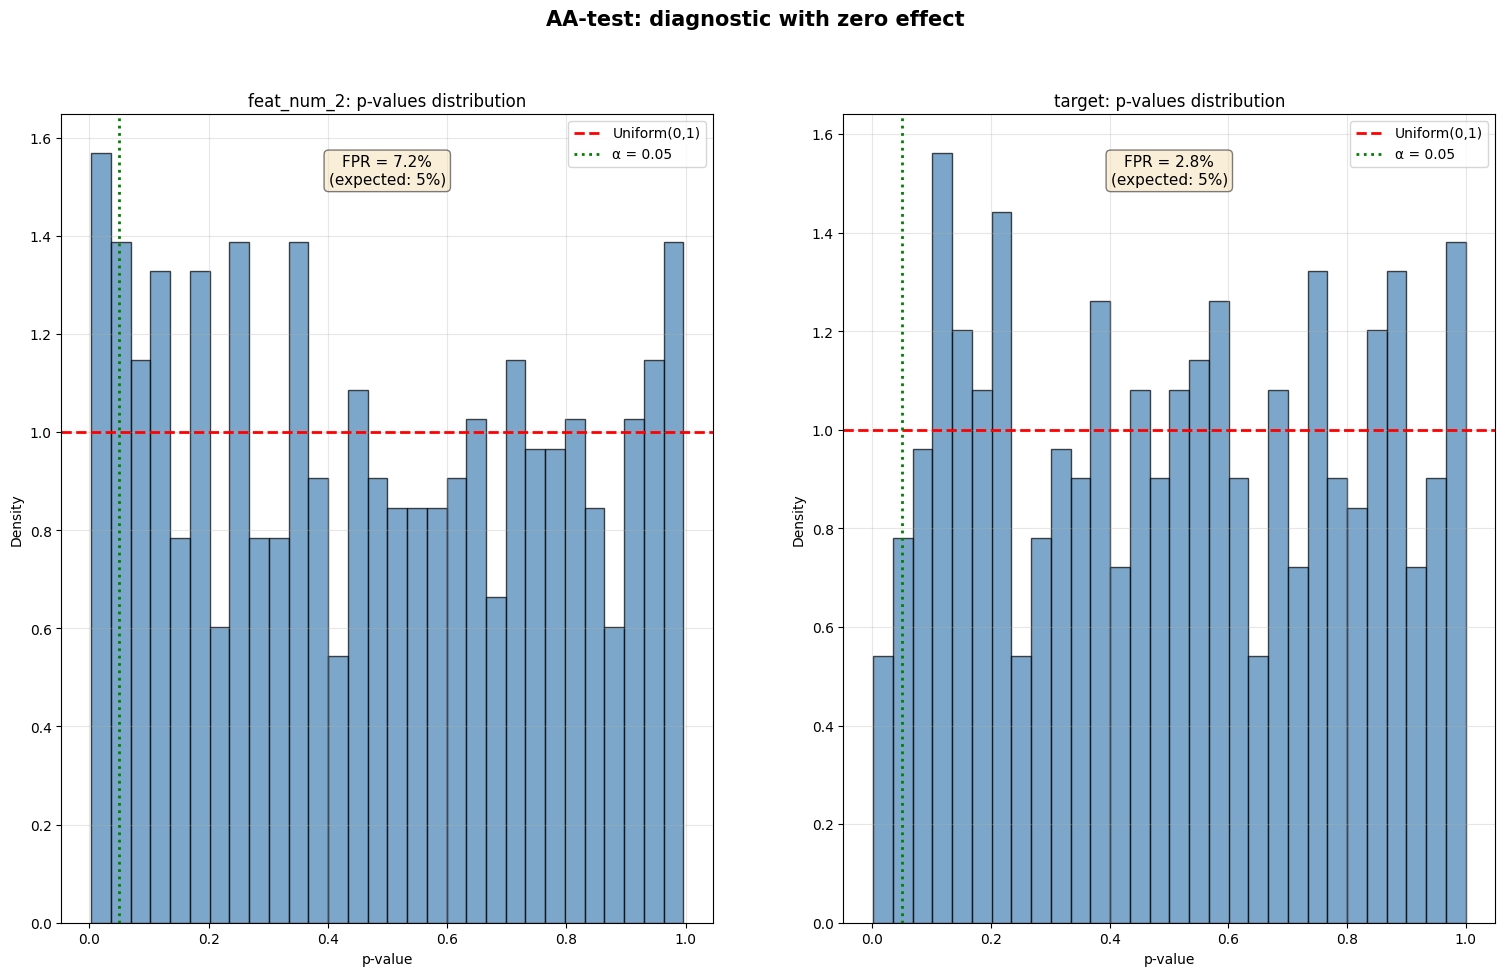

In [30]:
fig = exp_data.variables['AADryTestAnalyzer┴┴AATest']['AATest']
fig.set_size_inches(18.5, 10.5, forward=True)
fig